In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2.2.0
sys.version_info(major=3, minor=6, micro=9, releaselevel='final', serial=0)
matplotlib 3.2.1
numpy 1.18.5
pandas 1.0.4
sklearn 0.23.1
tensorflow 2.2.0
tensorflow.keras 2.3.0-tf


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block
        - HouseAge      median house age in block
        - AveRooms      average number of rooms
        - AveBedrms     average number of bedrooms
        - Population    block population
        - AveOccup      average house occupancy
        - Latitude      house block latitude
        - Longitude     house block longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
http://lib.stat.cmu.edu/datasets/

The target variable is the median house value for California districts.

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bur

In [3]:
from sklearn.model_selection import train_test_split

x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state = 7)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state = 11)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)


(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# RandomizedSearchCV
# 1. 因为是sklearn的接口，转化为sklearn的model
# 2. 定义参数集合
# 3. 搜索参数

def build_model(hidden_layers = 1,
                layer_size = 30,
                learning_rate = 3e-3):
    model = keras.models.Sequential()
    # 因为不知道第一个输入的shape是多大的，因此需要单独从for循环里拿出来，for循环里的是输出再次作为输入
    model.add(keras.layers.Dense(layer_size, activation='relu',
                                 input_shape=x_train.shape[1:]))
    for _ in range(hidden_layers - 1):
        model.add(keras.layers.Dense(layer_size,
                                     activation = 'relu'))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate)
    model.compile(loss = 'mse', optimizer = optimizer)
    return model

#KerasRegressor返回一个sk的model,build_fn是一个回调函数
sklearn_model = tf.keras.wrappers.scikit_learn.KerasRegressor(
    build_fn = build_model)
callbacks = [keras.callbacks.EarlyStopping(patience=5, min_delta=1e-2)]
#这是对sk封装tf的一个测试
history = sklearn_model.fit(x_train_scaled, y_train,
                            epochs = 10,
                            validation_data = (x_valid_scaled, y_valid),
                            callbacks = callbacks)

Epoch 1/10
363/363 [==============================] - 1s 3ms/step - loss: 1.2363 - val_loss: 0.7430
Epoch 2/10
363/363 [==============================] - 1s 2ms/step - loss: 0.6441 - val_loss: 0.6531
Epoch 3/10
363/363 [==============================] - 1s 2ms/step - loss: 0.5795 - val_loss: 0.5988
Epoch 4/10
363/363 [==============================] - 1s 2ms/step - loss: 0.5348 - val_loss: 0.5611
Epoch 5/10
363/363 [==============================] - 1s 2ms/step - loss: 0.5058 - val_loss: 0.5314
Epoch 6/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4822 - val_loss: 0.5143
Epoch 7/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4683 - val_loss: 0.4948
Epoch 8/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4559 - val_loss: 0.4864
Epoch 9/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4463 - val_loss: 0.4735
Epoch 10/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4370 - val_loss: 0.4611

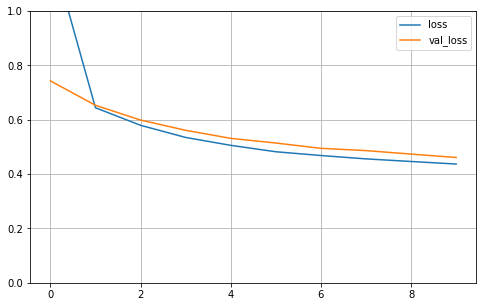

In [6]:
def plot_learning_curves(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.show()
plot_learning_curves(history)

In [7]:
#scipy也是sk中的
from scipy.stats import reciprocal
# 分布函数
# f(x) = 1/(x*log(b/a)) a <= x <= b

#sk 0.21.3版本可以用这种列表
# param_distribution = {
#     "hidden_layers":[1, 2, 3, 4],
#     "layer_size": np.arange(1, 100),
#     "learning_rate": reciprocal(1e-4, 1e-2),
# }
#最新版本只能用普通列表
param_distribution = {
    "hidden_layers": [1, 2, 3, 4],
    "layer_size": [5, 10, 20, 30],
    "learning_rate": [1e-4, 5e-5, 1e-3, 5e-3, 1e-2],
}

from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

#随机搜索
# random_search_cv = RandomizedSearchCV(sklearn_model,
#                                       param_distribution,
#                                       n_iter = 1,#多少个参数集合
#                                       n_jobs = -1)
grid_search_cv =GridSearchCV(sklearn_model,param_distribution)
# random_search_cv.fit(x_train_scaled, y_train, epochs = 100,
#                      validation_data = (x_valid_scaled, y_valid),
#                      callbacks = callbacks)

grid_search_cv.fit(x_train_scaled, y_train, epochs = 5,
                     validation_data = (x_valid_scaled, y_valid),
                     callbacks = callbacks)
# cross_validation: 训练集分成n份，n-1训练，最后一份验证.

Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 4.9459 - val_loss: 4.7581
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 4.1371 - val_loss: 4.0418
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 3.5317 - val_loss: 3.5086
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 3.0686 - val_loss: 3.0978
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 2.4852
Epoch 1/5
291/291 [==============================] - 1s 3ms/step - loss: 6.2377 - val_loss: 6.0355
Epoch 2/5
291/291 [==============================] - 1s 3ms/step - loss: 5.1369 - val_loss: 5.0748
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 4.3634 - val_loss: 4.3858
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 3.7987 - val_loss: 3.8745
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 3.2931
Epoch 1/5
291/291 [==============================] -

291/291 [==============================] - 1s 2ms/step - loss: 0.7681 - val_loss: 0.7637
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.7164
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 1.1311 - val_loss: 0.8337
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.7032 - val_loss: 0.6824
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.5971 - val_loss: 0.5966
Epoch 4/5
291/291 [==============================] - 0s 2ms/step - loss: 0.5435 - val_loss: 0.5576
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.4635
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 1.1343 - val_loss: 0.6993
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.6199 - val_loss: 0.6386
Epoch 3/5
291/291 [==============================] - 0s 2ms/step - loss: 0.5759 - val_loss: 0.6049
Epoch 4/5
291/291 [==============================] - 1s 2ms/st

Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 5.4926 - val_loss: 5.0326
Epoch 3/5
291/291 [==============================] - 1s 3ms/step - loss: 4.2089 - val_loss: 3.9490
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 3.3472 - val_loss: 3.2010
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 2.5487
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 4.9210 - val_loss: 5.1230
Epoch 2/5
291/291 [==============================] - 1s 3ms/step - loss: 4.3299 - val_loss: 4.5180
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 3.8411 - val_loss: 4.0171
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 3.4393 - val_loss: 3.5989
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 2.4699
Epoch 1/5
291/291 [==============================] - 1s 4ms/step - loss: 7.6480 - val_loss: 7.6853
Epoch 2/5
291/291 [==============================] -

73/73 [==============================] - 0s 1ms/step - loss: 0.5787
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 1.0229 - val_loss: 0.6539
Epoch 2/5
291/291 [==============================] - 0s 2ms/step - loss: 0.5648 - val_loss: 0.5612
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.5082 - val_loss: 0.5133
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4807 - val_loss: 0.5082
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.4782
Epoch 1/5
291/291 [==============================] - 1s 3ms/step - loss: 0.8676 - val_loss: 0.6579
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.7170 - val_loss: 0.5463
Epoch 3/5
291/291 [==============================] - 1s 3ms/step - loss: 0.5081 - val_loss: 0.5226
Epoch 4/5
291/291 [==============================] - 1s 3ms/step - loss: 0.4711 - val_loss: 0.4794
Epoch 5/5
73/73 [==============================] - 0s 1ms/step

291/291 [==============================] - 1s 3ms/step - loss: 3.1349 - val_loss: 3.0878
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 2.8139 - val_loss: 2.7968
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 2.5435 - val_loss: 2.5529
Epoch 5/5
73/73 [==============================] - 0s 2ms/step - loss: 2.1980
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 6.9047 - val_loss: 6.5225
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 5.8662 - val_loss: 5.6181
Epoch 3/5
291/291 [==============================] - 1s 3ms/step - loss: 5.0608 - val_loss: 4.9016
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 4.4238 - val_loss: 4.3223
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 3.8251
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 2.5005 - val_loss: 1.2468
Epoch 2/5
291/291 [==============================] - 0s 2ms/st

...

291/291 [==============================] - 1s 2ms/step - loss: 0.5091 - val_loss: 0.4949
Epoch 3/5
291/291 [==============================] - 0s 2ms/step - loss: 0.4550 - val_loss: 0.4552
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4296 - val_loss: 0.4385
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.4597
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 1.2239 - val_loss: 0.7321
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.6003 - val_loss: 0.5849
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4937 - val_loss: 0.5365
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4520 - val_loss: 0.4781
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.4672
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 4.2809 - val_loss: 3.8176
Epoch 2/5
291/291 [==============================] - 1s 2ms/st

73/73 [==============================] - 0s 1ms/step - loss: 0.6343
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 2.6468 - val_loss: 1.3044
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 1.0654 - val_loss: 0.9670
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.8482 - val_loss: 0.8040
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.7240 - val_loss: 0.7210
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.6353
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 2.0680 - val_loss: 1.0236
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.8463 - val_loss: 0.7883
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.7115 - val_loss: 0.7349
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.6669 - val_loss: 0.7079
Epoch 5/5
73/73 [==============================] - 0s 1ms/step

291/291 [==============================] - 1s 2ms/step - loss: 3.1797 - val_loss: 2.8200
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 2.3410 - val_loss: 2.1093
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 1.8383 - val_loss: 1.7151
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 1.4038
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 5.0030 - val_loss: 4.7851
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 4.2531 - val_loss: 4.0669
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 3.5863 - val_loss: 3.4131
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 2.9792 - val_loss: 2.8240
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 2.1456
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 4.8147 - val_loss: 4.5430
Epoch 2/5
291/291 [==============================] - 1s 2ms/st

73/73 [==============================] - 0s 1ms/step - loss: 0.4024
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 0.8810 - val_loss: 0.6391
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.5399 - val_loss: 0.5287
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4739 - val_loss: 0.4754
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4309 - val_loss: 0.4620
Epoch 5/5
73/73 [==============================] - 0s 1ms/step - loss: 0.3981
Epoch 1/5
291/291 [==============================] - 1s 2ms/step - loss: 0.8762 - val_loss: 0.5978
Epoch 2/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4990 - val_loss: 0.4872
Epoch 3/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4389 - val_loss: 0.4684
Epoch 4/5
291/291 [==============================] - 1s 2ms/step - loss: 0.4086 - val_loss: 0.4269
Epoch 5/5
73/73 [==============================] - 0s 1ms/step

GridSearchCV(estimator=<tensorflow.python.keras.wrappers.scikit_learn.KerasRegressor object at 0x7f1eae69c9b0>,
             param_grid={'hidden_layers': [1, 2, 3, 4],
                         'layer_size': [5, 10, 20, 30],
                         'learning_rate': [0.0001, 5e-05, 0.001, 0.005, 0.01]})

In [10]:
# print(random_search_cv.best_params_)
# print(random_search_cv.best_score_)
# print(random_search_cv.best_estimator_)

print(grid_search_cv.best_params_)
print(grid_search_cv.best_score_)
print(grid_search_cv.best_estimator_)

{'hidden_layers': 4, 'layer_size': 30, 'learning_rate': 0.01}
-0.3823438286781311


In [11]:
# model = random_search_cv.best_estimator_.model
# model.evaluate(x_test_scaled, y_test)

model = grid_search_cv.best_estimator_.model
model.evaluate(x_test_scaled, y_test)

162/162 [==============================] - 0s 1ms/step - loss: 0.3816


0.38159599900245667